# 10. Interactions, Heterogeneity, and Nonlinear Structure

The previous notebooks studied several explanation tools one at a time: global effect plots, permutation importance, SHAP values, and LIME-style local surrogates. This notebook connects them through one central modeling idea:

> A model is easy to summarize when each feature has roughly the same meaning everywhere. A model becomes harder to explain when the meaning of one feature depends on the values of other features.

That dependency is an **interaction**. In decision systems, interactions are not a technical footnote. They are often the reason a predictive model is useful at all. A small usage gap may be harmless for a lightly loaded account, but dangerous when support tickets are rising. Recent incidents may be tolerable when an executive sponsor is engaged, but serious when no sponsor exists. A global average explanation can flatten these distinctions into a story that is too smooth to guide action.

We will build this notebook around a customer-success risk workflow. The model predicts whether an account needs specialist review before renewal. The simulated data contain known nonlinear and interaction structure, so we can evaluate whether our interpretation tools actually recover it.

## Learning Objectives

By the end of this notebook, you should be able to:

1. Define an interaction as a failure of additive decomposition in a fitted prediction function.
2. Distinguish global main effects, local effects, subgroup effects, and pairwise interactions.
3. Use response surfaces, subgroup PDPs, centered ICE curves, and interaction residuals to diagnose nonlinear structure.
4. Compute a simple Friedman-style interaction strength statistic from partial dependence surfaces.
5. Explain why interaction diagnostics describe the fitted model, not causal effect heterogeneity by themselves.
6. Write a professional interaction report that says what was tested, where the model behaves differently, and what decision guardrails are needed.

## 1. Additive Models Versus Interaction Models

Let $f(x)$ be a fitted prediction function. Suppose $x=(x_1,\dots,x_p)$ and we focus on two features $x_j$ and $x_k$.

An additive model has the form

$$
f(x) = c + f_1(x_1) + f_2(x_2) + \cdots + f_p(x_p).
$$

In an additive model, the contribution of $x_j$ does not depend on $x_k$. The slope or shape of the response to training gap, for example, is the same whether ticket volume is low or high.

A model with a pairwise interaction includes a term such as

$$
f(x) = c + f_j(x_j) + f_k(x_k) + f_{jk}(x_j,x_k) + \text{other terms}.
$$

The interaction component $f_{jk}$ is the part of the joint response that cannot be explained by adding the two one-feature responses. In plain language:

> There is an interaction when the effect of one predictor on the fitted model changes depending on another predictor.

This is a statement about the **fitted model's response surface**. A causal heterogeneity claim would require a causal design.

## 2. Partial Dependence, ICE, and Interaction Residuals

A one-feature partial dependence function averages the fitted model over the empirical distribution of the other features:

$$
\operatorname{PD}_j(t)
= \frac{1}{n}\sum_{i=1}^{n} f(t, x_{i,-j}).
$$

A two-feature partial dependence surface is

$$
\operatorname{PD}_{jk}(s,t)
= \frac{1}{n}\sum_{i=1}^{n} f(s,t,x_{i,-(j,k)}).
$$

If features $j$ and $k$ act additively in the fitted function, then the two-feature surface should be approximated by the sum of the two one-feature effects. Define the centered main-effect functions

$$
\tilde{\operatorname{PD}}_j(s)=\operatorname{PD}_j(s)-\bar f,
\qquad
\tilde{\operatorname{PD}}_k(t)=\operatorname{PD}_k(t)-\bar f,
$$

where $\bar f$ is the average fitted prediction. A simple interaction residual is

$$
R_{jk}(s,t)
= \operatorname{PD}_{jk}(s,t)
- \tilde{\operatorname{PD}}_j(s)
- \tilde{\operatorname{PD}}_k(t)
- \bar f.
$$

When $R_{jk}(s,t)$ is near zero across the grid, the pair behaves additively in the fitted model. When it has structure, the joint surface contains interaction behavior. Friedman and Popescu's partial-dependence interaction logic uses this idea to construct interaction statistics (Friedman & Popescu, 2008). ICE plots disaggregate the average curve into one curve per observation, which helps reveal heterogeneous model behavior that a PDP can hide (Goldstein et al., 2015; Greenwell, 2017).

## 3. Interaction Diagnostics Are Model Diagnostics

Before coding, keep the interpretation boundary clear.

| Quantity | What it can tell us | What it cannot tell us by itself |
|---|---|---|
| Explicit interaction coefficient | Whether the fitted transparent model includes a non-additive term | Whether changing one variable would causally amplify another |
| Two-way PDP surface | How the fitted model's average prediction changes over a two-feature grid | Whether the grid values are all realistic or policy-reachable |
| ICE curve spread | Whether individual fitted responses differ across contexts | Whether response heterogeneity is causal, fair, or actionable |
| Interaction residual surface | Where the joint fitted response departs from additivity | Whether the departure is stable under retraining or data shift |
| Subgroup effect plot | Whether model behavior differs across named segments | Whether segment-specific policy should be launched |

A professional explanation workflow reports interactions as **evidence about model behavior**. Turning them into interventions requires causal design, operational feasibility checks, and governance review.

In [1]:
import os
os.environ.setdefault('MPLCONFIGDIR', '/tmp/matplotlib-cache')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, brier_score_loss, log_loss, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

RANDOM_SEED = 2060
sns.set_theme(style='whitegrid', context='notebook')
np.set_printoptions(precision=3, suppress=True)
pd.set_option('display.max_colwidth', 120)

In [2]:
# Section focus: 3. Interaction Diagnostics Are Model Diagnostics.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

def display_table(df, precision=3, max_width='420px'):
    """Display table for the 10. Interactions, Heterogeneity, and Nonlinear Structure notebook output.
    
    Parameters
    ----------
    df : object
        Input data frame containing the rows used in this notebook example.
    precision : object
        Number of decimal places used when formatting numeric output.
    max_width : object
        Maximum display width used to keep rendered tables readable.
    
    Returns
    -------
    object
        None. The function updates a plot, display object, or notebook state as its side effect.
    """
    styler = df.style.format(precision=precision)
    styler = styler.set_table_styles([
        {'selector': 'th', 'props': [('white-space', 'normal'), ('text-align', 'left')]},
        {'selector': 'td', 'props': [('white-space', 'normal'), ('max-width', max_width), ('text-align', 'left'), ('vertical-align', 'top')]},
    ])
    display(styler)


def sigmoid(z):
    """Map a linear score to a probability-like value for the notebook simulation.
    
    Parameters
    ----------
    z : object
        Linear predictor or standardized score being transformed by this helper.
    
    Returns
    -------
    object
        Numeric diagnostic, score, or transformed value from the sigmoid calculation.
    """
    return 1 / (1 + np.exp(-z))


def predict_risk(model, data, features):
    """Carry out the predict risk step used in the 10. Interactions, Heterogeneity, and Nonlinear Structure workflow.
    
    Parameters
    ----------
    model : object
        Fitted model or model specification used by this step.
    data : object
        Input data set used by this step of the notebook.
    features : object
        Feature column names or feature matrix used by the model.
    
    Returns
    -------
    object
        Numeric diagnostic, score, or transformed value from the predict risk calculation.
    """
    return model.predict_proba(data[features])[:, 1]


def classification_metrics(y_true, prob):
    """Carry out the classification metrics step used in the 10. Interactions, Heterogeneity, and Nonlinear Structure workflow.
    
    Parameters
    ----------
    y_true : object
        Observed target or outcome values used as ground truth for metric calculation.
    prob : object
        Rate or probability parameter controlling this calculation.
    
    Returns
    -------
    object
        Dictionary or table of metrics used to compare model behavior.
    """
    clipped = np.clip(prob, 1e-6, 1 - 1e-6)
    return {
        'roc_auc': roc_auc_score(y_true, prob),
        'average_precision': average_precision_score(y_true, prob),
        'brier_score': brier_score_loss(y_true, prob),
        'log_loss': log_loss(y_true, clipped),
        'mean_predicted_risk': float(np.mean(prob)),
    }

This result is an interpretation diagnostic. For Interaction Diagnostics Are Model Diagnostics, look at whether the explanation is stable, plausible, and useful for stakeholder review. Before this becomes decision support, the analyst should know which parts of the explanation are robust.


## 4. Synthetic Decision Case: Specialist Review Before Renewal

We simulate account-level data for a customer-success team. The model supports a decision: which accounts should receive specialist review before renewal?

The data-generating process deliberately includes several forms of structure:

| Structure | Business interpretation | Why it matters for interpretation |
|---|---|---|
| Usage gap and training gap move together | Accounts that underuse the product often also have training problems | A one-feature effect may average over different maturity contexts |
| Ticket burden interacts with incidents | Incidents are more alarming when they occur alongside many open tickets | A global ticket effect can hide threshold behavior |
| Executive sponsor changes the incident story | Incidents are less dangerous when a sponsor is engaged | Same incident count can mean different risk in different contexts |
| Legacy integration and international region interact | Complex implementation context amplifies operational friction | Segment explanations should be audited separately |
| Account size changes the cost of maturity gaps | Gaps are operationally more serious for large accounts | Local explanations may differ by account scale |

In [3]:
# Section focus: 4. Synthetic Decision Case: Specialist Review Before Renewal.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

def make_specialist_review_data(n=6200, seed=RANDOM_SEED):
    """Construct the specialist review data helper used in the 10. Interactions, Heterogeneity, and Nonlinear Structure workflow.
    
    Parameters
    ----------
    n : object
        Number of observations or simulation units used by the calculation.
    seed : object
        Random seed used to make the simulation reproducible.
    
    Returns
    -------
    object
        pandas.DataFrame containing the tabular result produced by this function.
    """
    rng = np.random.default_rng(seed)

    account_size = rng.normal(0, 1, n)
    international_region = rng.binomial(1, sigmoid(-0.65 + 0.55 * account_size), n)
    legacy_integration = rng.binomial(1, sigmoid(-0.85 + 0.65 * international_region + 0.35 * account_size), n)
    executive_sponsor = rng.binomial(1, sigmoid(0.05 + 0.75 * account_size - 0.25 * legacy_integration), n)

    maturity = rng.normal(0, 1, n) + 0.18 * executive_sponsor - 0.22 * legacy_integration - 0.14 * international_region
    usage_gap = np.clip(sigmoid(-0.15 - 0.90 * maturity + rng.normal(0, 0.70, n)), 0.02, 0.98)
    training_gap = np.clip(sigmoid(-0.05 - 0.75 * maturity + 0.55 * usage_gap + rng.normal(0, 0.65, n)), 0.02, 0.98)

    ticket_lambda = np.exp(0.45 + 0.95 * usage_gap + 0.65 * training_gap + 0.25 * legacy_integration)
    open_tickets = rng.poisson(np.clip(ticket_lambda, 0.2, 10.0))
    incident_lambda = np.exp(-1.15 + 0.22 * open_tickets + 0.75 * legacy_integration + 0.25 * international_region)
    recent_incidents = rng.poisson(np.clip(incident_lambda, 0.05, 8.0))

    billing_delay = np.clip(rng.gamma(1.7 + 0.6 * legacy_integration, 1.4, n), 0, 14)
    adoption_volatility = np.abs(rng.normal(0.32 + 0.65 * usage_gap + 0.20 * international_region, 0.22, n))
    random_noise_feature = rng.normal(0, 1, n)

    incident_pressure = np.maximum(recent_incidents - 2, 0)
    ticket_pressure = np.maximum(open_tickets - 3, 0)

    logit = (
        -4.10
        + 1.45 * usage_gap
        + 1.05 * training_gap
        + 0.16 * open_tickets
        + 0.36 * recent_incidents
        + 0.10 * billing_delay
        + 0.75 * legacy_integration
        + 0.42 * international_region
        - 0.72 * executive_sponsor
        + 1.85 * usage_gap * training_gap
        + 0.28 * ticket_pressure * incident_pressure
        + 0.92 * recent_incidents * (1 - executive_sponsor)
        + 0.88 * legacy_integration * international_region
        + 0.58 * account_size * usage_gap
        + 0.45 * adoption_volatility * legacy_integration
    )

    true_risk = sigmoid(logit)
    needs_specialist_review = rng.binomial(1, true_risk)

    df = pd.DataFrame({
        'account_size': account_size,
        'usage_gap': usage_gap,
        'training_gap': training_gap,
        'open_tickets': open_tickets,
        'recent_incidents': recent_incidents,
        'billing_delay_days': billing_delay,
        'adoption_volatility': adoption_volatility,
        'executive_sponsor': executive_sponsor,
        'international_region': international_region,
        'legacy_integration': legacy_integration,
        'random_noise_feature': random_noise_feature,
        'true_risk': true_risk,
        'needs_specialist_review': needs_specialist_review,
    })
    return df


df = make_specialist_review_data()
TARGET = 'needs_specialist_review'
BASE_FEATURES = [
    'account_size', 'usage_gap', 'training_gap', 'open_tickets', 'recent_incidents',
    'billing_delay_days', 'adoption_volatility', 'executive_sponsor',
    'international_region', 'legacy_integration', 'random_noise_feature'
]
NUMERIC_FEATURES = ['account_size', 'usage_gap', 'training_gap', 'open_tickets', 'recent_incidents', 'billing_delay_days', 'adoption_volatility', 'random_noise_feature']
BINARY_FEATURES = ['executive_sponsor', 'international_region', 'legacy_integration']

train_df, test_df = train_test_split(df, test_size=0.30, random_state=RANDOM_SEED, stratify=df[TARGET])

summary = pd.DataFrame([
    {'quantity': 'Rows', 'value': len(df)},
    {'quantity': 'Train rows', 'value': len(train_df)},
    {'quantity': 'Test rows', 'value': len(test_df)},
    {'quantity': 'Specialist-review rate', 'value': df[TARGET].mean()},
    {'quantity': 'Correlation: usage gap and training gap', 'value': df[['usage_gap', 'training_gap']].corr().iloc[0, 1]},
    {'quantity': 'Correlation: tickets and incidents', 'value': df[['open_tickets', 'recent_incidents']].corr().iloc[0, 1]},
])
display_table(summary)

display_table(df[BASE_FEATURES + [TARGET]].head(6))

,quantity,value
0,Rows,6200.000
1,Train rows,4340.000
2,Test rows,1860.000
3,Specialist-review rate,0.474
4,Correlation: usage gap and training gap,0.676
5,Correlation: tickets and incidents,0.630


,account_size,usage_gap,training_gap,open_tickets,recent_incidents,billing_delay_days,adoption_volatility,executive_sponsor,international_region,legacy_integration,random_noise_feature,needs_specialist_review
0,1.981,0.242,0.338,3,1,0.377,0.783,1,1,1,0.263,0
1,-0.542,0.178,0.357,3,4,4.156,0.385,0,1,1,0.477,1
2,-0.091,0.394,0.446,2,0,1.115,0.697,0,1,0,0.481,0
3,0.988,0.195,0.375,6,5,1.421,0.738,1,1,1,-0.344,1
4,0.805,0.768,0.521,5,3,0.321,0.425,0,0,1,0.602,1
5,0.828,0.915,0.881,8,1,2.329,0.773,1,1,0,1.420,0


This output matters because the result has to support an operating decision. For Synthetic Decision Case: Specialist Review Before Renewal, the result should tell us which cases are actionable, which are ambiguous, and where human review is needed. The implication is an operating policy with an investigation path.


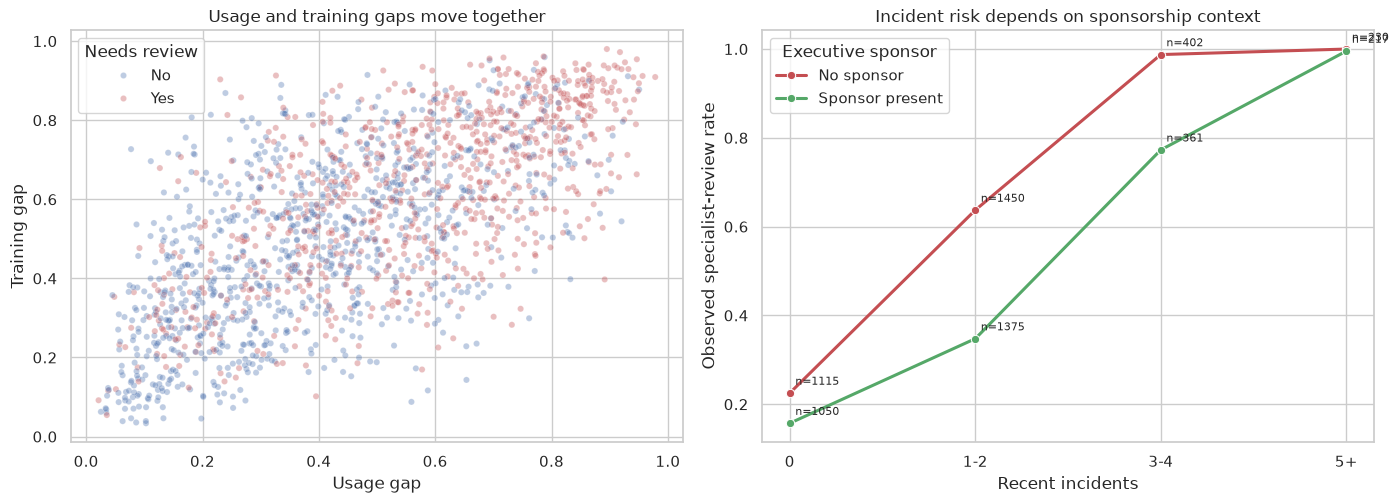

In [4]:
# Section focus: 4. Synthetic Decision Case: Specialist Review Before Renewal.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

fig, axes = plt.subplots(1, 2, figsize=(14.2, 5.2))

plot_sample = df.sample(1800, random_state=RANDOM_SEED).copy()
plot_sample['review_label'] = np.where(plot_sample[TARGET].eq(1), 'Yes', 'No')
sns.scatterplot(
    data=plot_sample,
    x='usage_gap',
    y='training_gap',
    hue='review_label',
    hue_order=['No', 'Yes'],
    palette={'No': '#4c72b0', 'Yes': '#c44e52'},
    alpha=0.36,
    s=20,
    ax=axes[0],
)
axes[0].set_title('Usage and training gaps move together')
axes[0].set_xlabel('Usage gap')
axes[0].set_ylabel('Training gap')
axes[0].legend(title='Needs review', loc='upper left')

incident_bins = pd.cut(df['recent_incidents'], bins=[-0.1, 0.5, 2.5, 4.5, 20], labels=['0', '1-2', '3-4', '5+'])
incident_summary = (
    df.assign(incident_bin=incident_bins, sponsor_label=np.where(df['executive_sponsor'].eq(1), 'Sponsor present', 'No sponsor'))
      .groupby(['incident_bin', 'sponsor_label'], observed=False)[TARGET]
      .agg(['mean', 'size'])
      .reset_index()
)
sns.lineplot(
    data=incident_summary,
    x='incident_bin',
    y='mean',
    hue='sponsor_label',
    marker='o',
    linewidth=2.2,
    palette={'Sponsor present': '#55a868', 'No sponsor': '#c44e52'},
    ax=axes[1],
)
for _, row in incident_summary.iterrows():
    axes[1].annotate(f"n={int(row['size'])}", (row['incident_bin'], row['mean']), textcoords='offset points', xytext=(4, 6), fontsize=8)
axes[1].set_title('Incident risk depends on sponsorship context')
axes[1].set_xlabel('Recent incidents')
axes[1].set_ylabel('Observed specialist-review rate')
axes[1].legend(title='Executive sponsor')

plt.tight_layout()
plt.show()

Read Synthetic Decision Case: Specialist Review Before Renewal as a stress test for the explanation. Stable reasons strengthen the story; shifting local reasons should stay in the caveats.


### Discussion of the Data Design

The first plot shows correlated maturity signals. The second plot previews a strong interaction: incident count matters much more when no executive sponsor is present. A single global incident coefficient would miss that operational context.

This is the central reason interaction diagnostics matter. In a real deployment, the team may ask whether incidents predict risk and how that relationship changes across segments:

- For whom are incidents most concerning?
- Which segment receives a different model story?
- Which combinations of signals should trigger review rather than just monitoring?

The dataset is built around a common operational pattern: the same signal can mean different things in different contexts. Incidents are more concerning when sponsorship is weak, and low adoption is more concerning when training gaps are large. These interactions are hard to summarize with one global coefficient.

The experiment compares models and explanations that either flatten or preserve that heterogeneity. The goal is to improve predictive metrics and make the interaction structure legible enough that a team can decide whether different account segments need different playbooks.


## 5. Fit Additive, Explicit-Interaction, and Flexible Models

We fit three models:

| Model | Purpose |
|---|---|
| Additive logistic regression | Transparent baseline with one global coefficient per feature |
| Logistic regression with explicit interactions | Transparent model that can represent selected non-additive business logic |
| Histogram gradient boosting | Flexible nonlinear benchmark that can learn thresholds and interactions automatically |

This comparison is important. If the interaction-aware transparent model performs nearly as well as the flexible benchmark, it may be easier to govern. If the flexible model clearly wins, explanation tools become more important.

In [5]:
# Section focus: 5. Fit Additive, Explicit-Interaction, and Flexible Models.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

def add_interaction_features(data):
    """Carry out the add interaction features step used in the 10. Interactions, Heterogeneity, and Nonlinear Structure workflow.
    
    Parameters
    ----------
    data : object
        Input data set used by this step of the notebook.
    
    Returns
    -------
    object
        Tabular or matrix-style object produced by the add interaction features workflow for later analysis.
    """
    out = data.copy()
    out['usage_x_training_gap'] = out['usage_gap'] * out['training_gap']
    out['tickets_x_incidents'] = np.maximum(out['open_tickets'] - 3, 0) * np.maximum(out['recent_incidents'] - 2, 0)
    out['incidents_x_no_sponsor'] = out['recent_incidents'] * (1 - out['executive_sponsor'])
    out['legacy_x_international'] = out['legacy_integration'] * out['international_region']
    out['size_x_usage_gap'] = out['account_size'] * out['usage_gap']
    return out

INTERACTION_FEATURES = BASE_FEATURES + [
    'usage_x_training_gap',
    'tickets_x_incidents',
    'incidents_x_no_sponsor',
    'legacy_x_international',
    'size_x_usage_gap',
]

train_int = add_interaction_features(train_df)
test_int = add_interaction_features(test_df)

additive_logit = Pipeline([
    ('scale', StandardScaler()),
    ('model', LogisticRegression(max_iter=4000, C=0.9, solver='lbfgs')),
])
interaction_logit = Pipeline([
    ('scale', StandardScaler()),
    ('model', LogisticRegression(max_iter=4000, C=0.9, solver='lbfgs')),
])
gradient_boosting = HistGradientBoostingClassifier(
    max_iter=260,
    learning_rate=0.045,
    max_leaf_nodes=24,
    l2_regularization=0.025,
    random_state=RANDOM_SEED,
)
random_forest = RandomForestClassifier(
    n_estimators=320,
    min_samples_leaf=24,
    max_features='sqrt',
    random_state=RANDOM_SEED,
    n_jobs=-1,
)

additive_logit.fit(train_df[BASE_FEATURES], train_df[TARGET])
interaction_logit.fit(train_int[INTERACTION_FEATURES], train_int[TARGET])
gradient_boosting.fit(train_df[BASE_FEATURES], train_df[TARGET])
random_forest.fit(train_df[BASE_FEATURES], train_df[TARGET])

model_specs = {
    'Additive logistic': (additive_logit, BASE_FEATURES, test_df),
    'Interaction logistic': (interaction_logit, INTERACTION_FEATURES, test_int),
    'Gradient boosting': (gradient_boosting, BASE_FEATURES, test_df),
    'Random forest': (random_forest, BASE_FEATURES, test_df),
}

metric_rows = []
for name, (model, features, data) in model_specs.items():
    prob = predict_risk(model, data, features)
    metric_rows.append({'model': name, **classification_metrics(data[TARGET], prob)})

metrics = pd.DataFrame(metric_rows).sort_values('roc_auc', ascending=False).reset_index(drop=True)
display_table(metrics)

,model,roc_auc,average_precision,brier_score,log_loss,mean_predicted_risk
0,Interaction logistic,0.908,0.915,0.120,0.375,0.472
1,Additive logistic,0.904,0.912,0.123,0.383,0.470
2,Random forest,0.897,0.903,0.131,0.410,0.472
3,Gradient boosting,0.890,0.901,0.132,0.413,0.474


The explanation result should be compared with the decision story. In Fit Additive, Explicit-Interaction, and Flexible Models, stable features, changing local reasons, and disagreement across explainers tell us how much trust to place in the model narrative. The analyst should treat a weak explanation as a signal to revisit the model story.


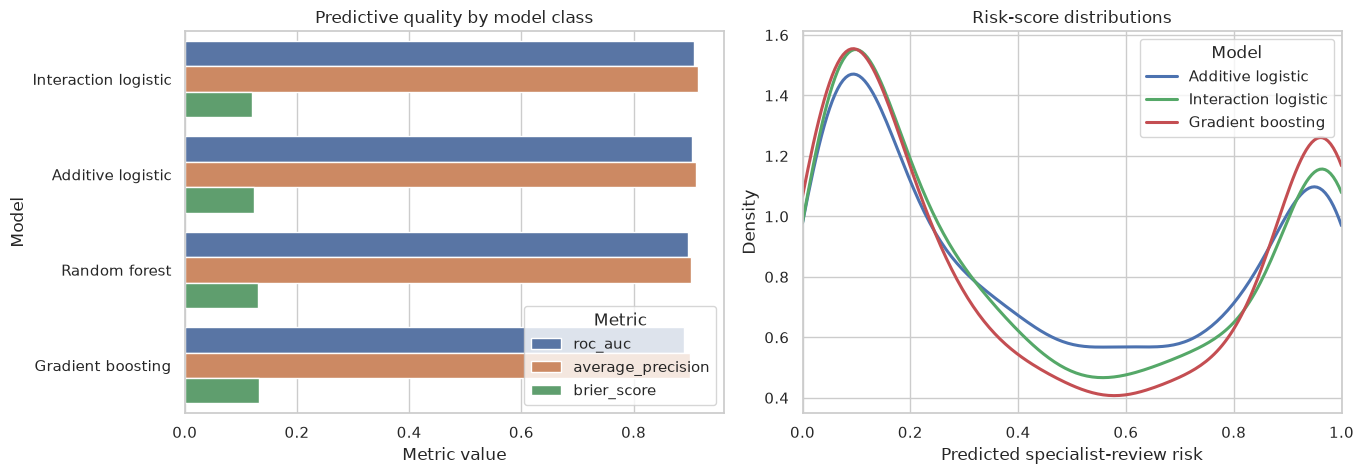

In [6]:
# Section focus: 5. Fit Additive, Explicit-Interaction, and Flexible Models.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

fig, axes = plt.subplots(1, 2, figsize=(13.8, 4.9))

metric_long = metrics.melt(
    id_vars='model',
    value_vars=['roc_auc', 'average_precision', 'brier_score'],
    var_name='metric',
    value_name='value',
)
sns.barplot(data=metric_long, x='value', y='model', hue='metric', ax=axes[0], palette='deep')
axes[0].set_title('Predictive quality by model class')
axes[0].set_xlabel('Metric value')
axes[0].set_ylabel('Model')
axes[0].legend(title='Metric', loc='lower right')

for name, (model, features, data), color in [
    ('Additive logistic', model_specs['Additive logistic'], '#4c72b0'),
    ('Interaction logistic', model_specs['Interaction logistic'], '#55a868'),
    ('Gradient boosting', model_specs['Gradient boosting'], '#c44e52'),
]:
    prob = predict_risk(model, data, features)
    sns.kdeplot(prob, label=name, color=color, linewidth=2.2, ax=axes[1], clip=(0, 1))
axes[1].set_title('Risk-score distributions')
axes[1].set_xlabel('Predicted specialist-review risk')
axes[1].set_ylabel('Density')
axes[1].set_xlim(0, 1)
axes[1].legend(title='Model')

plt.tight_layout()
plt.show()

This result is an interpretation diagnostic. For Fit Additive, Explicit-Interaction, and Flexible Models, look at whether the explanation is stable, plausible, and useful for stakeholder review. This kind of narrative should guide questions, not close them too early.


### Discussion of Model Comparison

The additive model is useful, and in this simulation it remains very competitive. The interaction logistic model improves the held-out metrics slightly because it includes terms aligned with the known data-generating structure. That small improvement is itself an important lesson: interactions do not always create a dramatic AUC jump, especially when the main effects already carry strong signal.

The tree models provide a flexible benchmark. They can discover threshold and interaction behavior without explicitly hand-engineered terms, but here they do not dominate the transparent interaction model. That makes the transparent model especially attractive for a governed decision workflow.

The key professional question asks which model produces useful interaction evidence and whether the AUC gain is meaningful:

> How much interpretability are we giving up, and what decision quality are we gaining?

If a transparent interaction model performs close to the black-box benchmark, it may be preferable for high-stakes deployment. If the black-box model is materially better, the interpretation burden rises.

## 6. Reading Explicit Interaction Terms

An explicit interaction model lets us inspect known candidate interactions directly. For a logistic model, the linear predictor is

$$
\eta(x)=\beta_0 + \sum_j \beta_j x_j + \sum_{j<k}\gamma_{jk}x_jx_k.
$$

For two numeric variables, the interaction coefficient $\gamma_{jk}$ changes the derivative of the log-odds with respect to $x_j$:

$$
\frac{\partial \eta(x)}{\partial x_j}=\beta_j + \gamma_{jk}x_k.
$$

But the probability-scale effect is

$$
\frac{\partial p(x)}{\partial x_j}
= p(x)(1-p(x))\left(\beta_j + \gamma_{jk}x_k\right),
$$

so both the interaction term and the baseline risk level matter. This is why interaction coefficients should usually be paired with response-surface plots.

,feature,standardized_log_odds_coefficient,term_type
12,tickets_x_incidents,1.816,Explicit interaction
13,incidents_x_no_sponsor,1.397,Explicit interaction
4,recent_incidents,0.748,Main effect
1,usage_gap,0.532,Main effect
9,legacy_integration,0.475,Main effect
3,open_tickets,0.439,Main effect
14,legacy_x_international,0.407,Explicit interaction
15,size_x_usage_gap,0.353,Explicit interaction
7,executive_sponsor,-0.352,Main effect
2,training_gap,0.208,Main effect


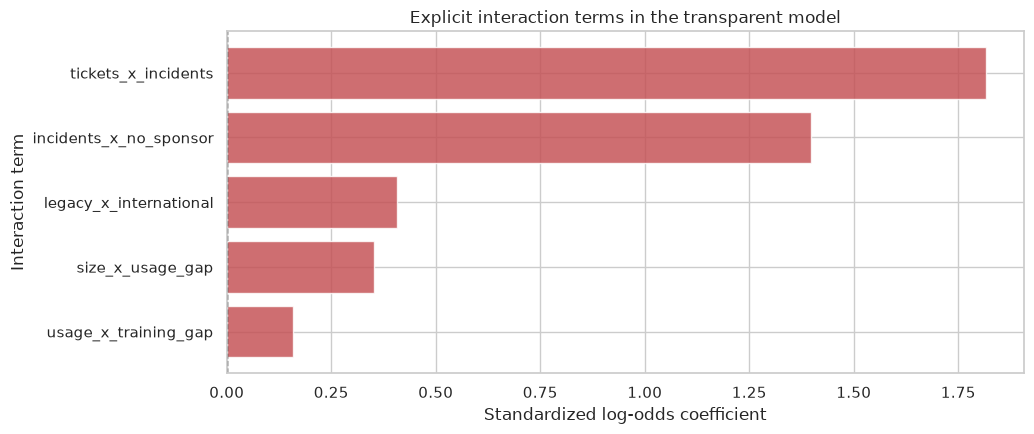

In [7]:
coef_table = pd.DataFrame({
    'feature': INTERACTION_FEATURES,
    'standardized_log_odds_coefficient': interaction_logit.named_steps['model'].coef_[0],
})
coef_table['abs_coefficient'] = coef_table['standardized_log_odds_coefficient'].abs()
coef_table['term_type'] = np.where(coef_table['feature'].str.contains('_x_'), 'Explicit interaction', 'Main effect')
coef_display = coef_table.sort_values('abs_coefficient', ascending=False).drop(columns='abs_coefficient')
display_table(coef_display.head(14))

interaction_only = coef_table[coef_table['term_type'].eq('Explicit interaction')].sort_values('abs_coefficient', ascending=True)
fig, ax = plt.subplots(figsize=(10.5, 4.5))
colors = np.where(interaction_only['standardized_log_odds_coefficient'] >= 0, '#c44e52', '#4c72b0')
ax.barh(interaction_only['feature'], interaction_only['standardized_log_odds_coefficient'], color=colors, alpha=0.82)
ax.axvline(0, color='black', linewidth=1, linestyle='--')
ax.set_title('Explicit interaction terms in the transparent model')
ax.set_xlabel('Standardized log-odds coefficient')
ax.set_ylabel('Interaction term')
plt.tight_layout()
plt.show()

This figure is meant to make the pattern visible. In Reading Explicit Interaction Terms, the shape, separation, overlap, tail behavior, or clustering should be tied back to a modeling choice or guardrail. A decision workflow should use the visual pattern to decide where the model is credible and where the next diagnostic needs attention.


### Discussion of Explicit Interactions

The coefficient table is useful because it names the interaction. For example, a positive `usage_x_training_gap` term means that the model treats simultaneous usage and training gaps as more serious than either gap alone.

But coefficients alone are incomplete. In logistic regression, the same log-odds interaction can translate into different probability changes depending on the account's baseline risk. That is why the next sections move from coefficients to surfaces and curves.

## 7. Response Surfaces: Seeing The Joint Shape

A two-feature response surface asks:

> What would the fitted model predict across a grid of two features, averaging or fixing the remaining features?

For a decision scientist, a surface is often more honest than a coefficient table. It can show threshold zones, saturation, and combinations of features that deserve special review.

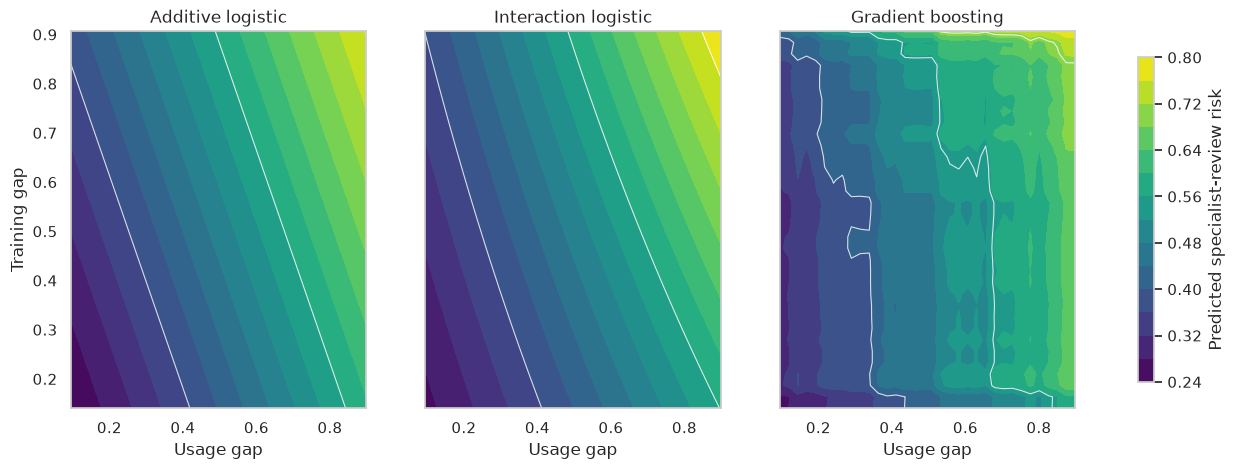

In [8]:
# Section focus: 7. Response Surfaces: Seeing The Joint Shape.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

def response_surface(model, base_data, features, x_feature, y_feature, x_grid, y_grid, sample_size=900, seed=RANDOM_SEED):
    """Carry out the response surface step used in the 10. Interactions, Heterogeneity, and Nonlinear Structure workflow.
    
    Parameters
    ----------
    model : object
        Fitted model or model specification used by this step.
    base_data : object
        The base data setting that controls the response surface calculation in this notebook.
    features : object
        Feature column names or feature matrix used by the model.
    x_feature : object
        Column or variable name used to select information from the input table.
    y_feature : object
        Column or variable name used to select information from the input table.
    x_grid : object
        Feature row, feature matrix, or covariate value passed into the model workflow.
    y_grid : object
        The y grid setting that controls the response surface calculation in this notebook.
    sample_size : object
        Number of units assigned to the simulated experiment or power calculation.
    seed : object
        Random seed used to make the simulation reproducible.
    
    Returns
    -------
    object
        Text or structured language-model artifact produced by the response surface workflow.
    """
    rng = np.random.default_rng(seed)
    sample = base_data.sample(min(sample_size, len(base_data)), random_state=seed).copy()
    surface = np.zeros((len(y_grid), len(x_grid)))
    for iy, yval in enumerate(y_grid):
        for ix, xval in enumerate(x_grid):
            temp = sample.copy()
            temp[x_feature] = xval
            temp[y_feature] = yval
            if set(INTERACTION_FEATURES).issubset(set(features)):
                temp = add_interaction_features(temp)
            surface[iy, ix] = predict_risk(model, temp, features).mean()
    return surface

x_grid = np.linspace(test_df['usage_gap'].quantile(0.03), test_df['usage_gap'].quantile(0.97), 34)
y_grid = np.linspace(test_df['training_gap'].quantile(0.03), test_df['training_gap'].quantile(0.97), 34)

surf_add = response_surface(additive_logit, test_df, BASE_FEATURES, 'usage_gap', 'training_gap', x_grid, y_grid)
surf_int = response_surface(interaction_logit, test_df, INTERACTION_FEATURES, 'usage_gap', 'training_gap', x_grid, y_grid)
surf_gb = response_surface(gradient_boosting, test_df, BASE_FEATURES, 'usage_gap', 'training_gap', x_grid, y_grid)

fig, axes = plt.subplots(1, 3, figsize=(16.2, 4.9), sharex=True, sharey=True)
for ax, surface, title in zip(
    axes,
    [surf_add, surf_int, surf_gb],
    ['Additive logistic', 'Interaction logistic', 'Gradient boosting'],
):
    contour = ax.contourf(x_grid, y_grid, surface, levels=16, cmap='viridis')
    ax.contour(x_grid, y_grid, surface, levels=[0.25, 0.40, 0.55, 0.70], colors='white', linewidths=0.8, alpha=0.8)
    ax.set_title(title)
    ax.set_xlabel('Usage gap')
axes[0].set_ylabel('Training gap')
fig.colorbar(contour, ax=axes, shrink=0.86, label='Predicted specialist-review risk')
plt.show()

Use the explanation as a stress test of the model narrative. In Response Surfaces: Seeing The Joint Shape, the displayed reasons should make sense with the data-generating story and the operating decision. When the views disagree, the safest communication is precise and qualified.


### Discussion of Response Surfaces

The additive surface can tilt smoothly, but it cannot represent the extra risk created by the combination of high usage gap and high training gap. The interaction-aware and flexible models can bend the surface upward in the high-gap corner.

This distinction matters for policy. A team using the additive model may under-prioritize accounts where two moderate signals combine into a serious risk pattern. A team using a flexible model needs explanation diagnostics to document where those combined signals matter.

## 8. ICE Curves: Heterogeneity Hidden By Averages

A PDP is an average curve. An ICE curve is one observation's curve:

$$
\operatorname{ICE}_{i,j}(t)=f(t,x_{i,-j}).
$$

If all ICE curves are nearly parallel, the feature has a similar fitted meaning across observations. If the curves fan out or cross, the feature's fitted meaning depends on context. Goldstein et al. (2015) introduced ICE plots precisely to disaggregate the average partial relationship and expose this kind of heterogeneity.

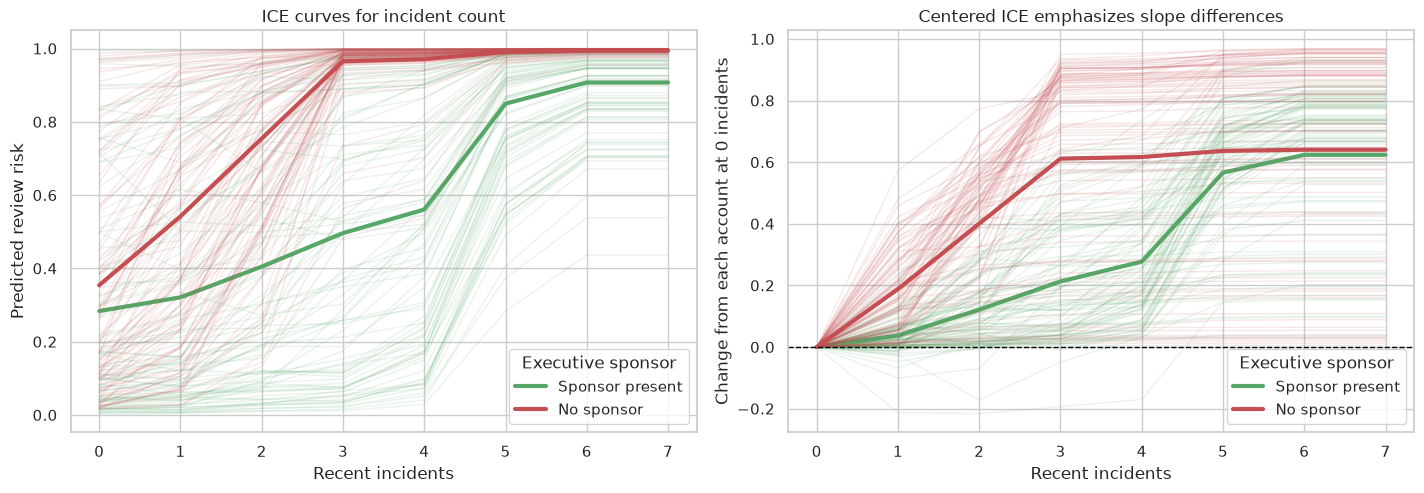

In [9]:
# Section focus: 8. ICE Curves: Heterogeneity Hidden By Averages.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

def ice_curves(model, data, features, feature, grid, sample_size=220, seed=RANDOM_SEED):
    """Carry out the ice curves step used in the 10. Interactions, Heterogeneity, and Nonlinear Structure workflow.
    
    Parameters
    ----------
    model : object
        Fitted model or model specification used by this step.
    data : object
        Input data set used by this step of the notebook.
    features : object
        Feature column names or feature matrix used by the model.
    feature : object
        Column or variable name used to select information from the input table.
    grid : object
        Grid of candidate values used for plotting, tuning, or sensitivity analysis.
    sample_size : object
        Number of units assigned to the simulated experiment or power calculation.
    seed : object
        Random seed used to make the simulation reproducible.
    
    Returns
    -------
    object
        Tuple of outputs from this workflow, usually data, fitted objects, or diagnostics used by later cells.
    """
    sample = data.sample(min(sample_size, len(data)), random_state=seed).copy()
    curves = []
    for val in grid:
        temp = sample.copy()
        temp[feature] = val
        if set(INTERACTION_FEATURES).issubset(set(features)):
            temp = add_interaction_features(temp)
        curves.append(predict_risk(model, temp, features))
    curves = np.vstack(curves).T
    return sample, curves

incident_grid = np.arange(0, 8)
ice_sample, ice = ice_curves(gradient_boosting, test_df, BASE_FEATURES, 'recent_incidents', incident_grid, sample_size=260)
centered_ice = ice - ice[:, [0]]

sample_labels = np.where(ice_sample['executive_sponsor'].eq(1), 'Sponsor present', 'No sponsor')
palette = {'Sponsor present': '#55a868', 'No sponsor': '#c44e52'}

fig, axes = plt.subplots(1, 2, figsize=(14.4, 5.1), sharex=True)
for label in ['Sponsor present', 'No sponsor']:
    idx = np.where(sample_labels == label)[0]
    for row in idx[:95]:
        axes[0].plot(incident_grid, ice[row], color=palette[label], alpha=0.13, linewidth=1)
    axes[0].plot(incident_grid, ice[idx].mean(axis=0), color=palette[label], linewidth=3, label=label)
axes[0].set_title('ICE curves for incident count')
axes[0].set_xlabel('Recent incidents')
axes[0].set_ylabel('Predicted review risk')
axes[0].legend(title='Executive sponsor')

for label in ['Sponsor present', 'No sponsor']:
    idx = np.where(sample_labels == label)[0]
    for row in idx[:95]:
        axes[1].plot(incident_grid, centered_ice[row], color=palette[label], alpha=0.13, linewidth=1)
    axes[1].plot(incident_grid, centered_ice[idx].mean(axis=0), color=palette[label], linewidth=3, label=label)
axes[1].axhline(0, color='black', linewidth=1, linestyle='--')
axes[1].set_title('Centered ICE emphasizes slope differences')
axes[1].set_xlabel('Recent incidents')
axes[1].set_ylabel('Change from each account at 0 incidents')
axes[1].legend(title='Executive sponsor')

plt.tight_layout()
plt.show()

This result is an interpretation diagnostic. For ICE Curves: Heterogeneity Hidden By Averages, look at whether the explanation is stable, plausible, and useful for stakeholder review. The model story should be framed as tentative until the explanation stabilizes.


In [10]:
ice_slope_summary = []
for label in ['Sponsor present', 'No sponsor']:
    idx = np.where(sample_labels == label)[0]
    slope = ice[idx, -1] - ice[idx, 0]
    ice_slope_summary.append({
        'segment': label,
        'n_accounts': len(idx),
        'mean_risk_change_0_to_7_incidents': slope.mean(),
        'p10_change': np.quantile(slope, 0.10),
        'p90_change': np.quantile(slope, 0.90),
    })

display_table(pd.DataFrame(ice_slope_summary))

,segment,n_accounts,mean_risk_change_0_to_7_incidents,p10_change,p90_change
0,Sponsor present,134,0.624,0.226,0.845
1,No sponsor,126,0.640,0.107,0.951


The explanation result should be compared with the decision story. In ICE Curves: Heterogeneity Hidden By Averages, stable features, changing local reasons, and disagreement across explainers tell us how much trust to place in the model narrative. The goal is to reduce ambiguity without hiding uncertainty.


### Discussion of ICE Heterogeneity

The centered ICE plot is the key diagnostic. It strips away starting risk and asks whether the model's incident-response shape differs by context. The no-sponsor curve rises earlier and saturates quickly, while the sponsor-present curve rises more gradually and catches up at high incident counts. That is why the 0-to-7 mean change table can look similar even though the path through the incident range is different.

This is a visible interaction between incident burden and sponsorship context. It is also a good reporting habit. If an analyst only shows a single PDP for incident count, the audience may assume incident count means the same thing everywhere. ICE curves show whether that assumption is defensible.

## 9. Subgroup PDPs: Named Contexts For Decision Review

ICE curves are rich but visually dense. For stakeholders, subgroup PDPs can be easier to read. A subgroup PDP estimates the average fitted response separately within meaningful segments:

$$
\operatorname{PD}_{j,g}(t)
= \frac{1}{n_g}\sum_{i:G_i=g} f(t,x_{i,-j}).
$$

This is not a causal subgroup effect. It is a model-behavior summary for a named context.

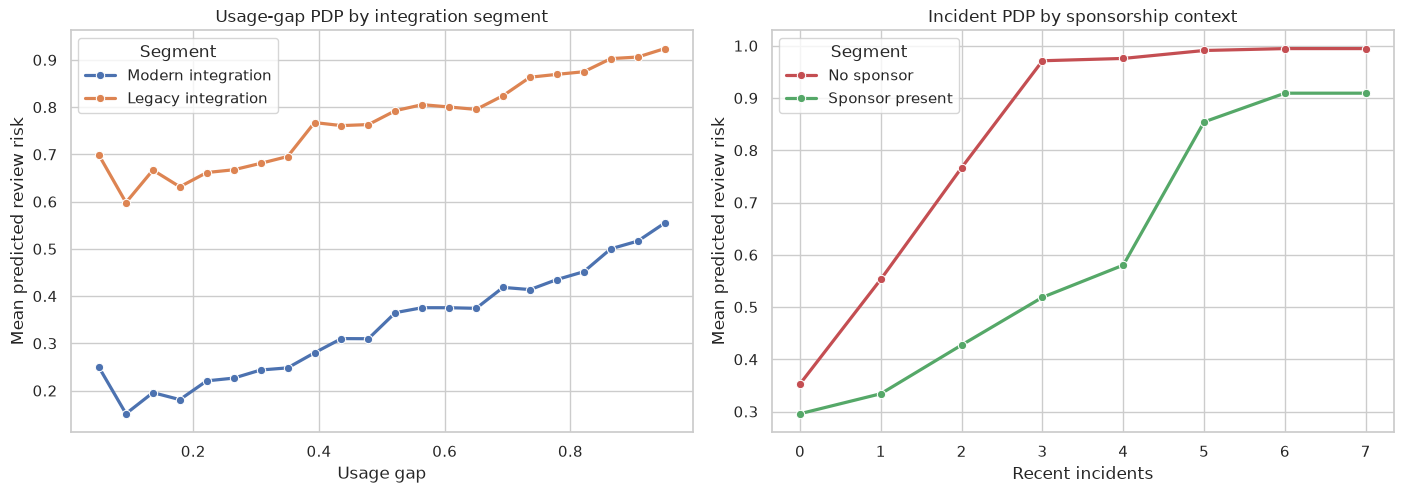

In [11]:
# Section focus: 9. Subgroup PDPs: Named Contexts For Decision Review.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

def subgroup_pd(model, data, features, feature, grid, group_col, group_labels):
    """Carry out the subgroup pd step used in the 10. Interactions, Heterogeneity, and Nonlinear Structure workflow.
    
    Parameters
    ----------
    model : object
        Fitted model or model specification used by this step.
    data : object
        Input data set used by this step of the notebook.
    features : object
        Feature column names or feature matrix used by the model.
    feature : object
        Column or variable name used to select information from the input table.
    grid : object
        Grid of candidate values used for plotting, tuning, or sensitivity analysis.
    group_col : object
        Column name identifying the group or segment used for comparison.
    group_labels : object
        Display setting used to make the plot or table readable in the rendered notebook.
    
    Returns
    -------
    object
        pandas.DataFrame containing the tabular result produced by this function.
    """
    rows = []
    for group_value, label in group_labels.items():
        subgroup = data[data[group_col].eq(group_value)].copy()
        for val in grid:
            temp = subgroup.copy()
            temp[feature] = val
            if set(INTERACTION_FEATURES).issubset(set(features)):
                temp = add_interaction_features(temp)
            rows.append({
                'group': label,
                feature: val,
                'mean_prediction': predict_risk(model, temp, features).mean(),
                'n': len(subgroup),
            })
    return pd.DataFrame(rows)

subgroup_usage = subgroup_pd(
    gradient_boosting,
    test_df,
    BASE_FEATURES,
    'usage_gap',
    np.linspace(0.05, 0.95, 22),
    'legacy_integration',
    {0: 'Modern integration', 1: 'Legacy integration'},
)
subgroup_incidents = subgroup_pd(
    gradient_boosting,
    test_df,
    BASE_FEATURES,
    'recent_incidents',
    np.arange(0, 8),
    'executive_sponsor',
    {0: 'No sponsor', 1: 'Sponsor present'},
)

fig, axes = plt.subplots(1, 2, figsize=(14.2, 5.1))
sns.lineplot(data=subgroup_usage, x='usage_gap', y='mean_prediction', hue='group', marker='o', linewidth=2.3, ax=axes[0])
axes[0].set_title('Usage-gap PDP by integration segment')
axes[0].set_xlabel('Usage gap')
axes[0].set_ylabel('Mean predicted review risk')
axes[0].legend(title='Segment')

sns.lineplot(data=subgroup_incidents, x='recent_incidents', y='mean_prediction', hue='group', marker='o', linewidth=2.3, ax=axes[1], palette={'No sponsor': '#c44e52', 'Sponsor present': '#55a868'})
axes[1].set_title('Incident PDP by sponsorship context')
axes[1].set_xlabel('Recent incidents')
axes[1].set_ylabel('Mean predicted review risk')
axes[1].legend(title='Segment')

plt.tight_layout()
plt.show()

Read Subgroup PDPs: Named Contexts For Decision Review as a communication test. Clarity and stability are both part of explanation quality.


### Discussion of Subgroup PDPs

The subgroup curves translate interaction structure into operational language. The same usage gap may be more serious for legacy integrations, and the same incident count may be more serious when no sponsor is present.

This is often the right compromise for a stakeholder report: enough heterogeneity to prevent a misleading average, but not so many curves that the plot becomes unreadable.

## 10. Friedman-Style Interaction Strength From Partial Dependence

A pairwise interaction statistic compares the joint partial dependence surface to the additive approximation built from the two one-feature partial dependences.

Let $S_{jk}$ be a grid over features $j$ and $k$. A simple normalized statistic is

$$
H^2_{jk}
= \frac{\sum_{(s,t)\in S_{jk}} R_{jk}(s,t)^2}
{\sum_{(s,t)\in S_{jk}} \left(\operatorname{PD}_{jk}(s,t)-\bar f\right)^2}.
$$

Values near zero suggest that the joint surface is close to additive on the grid. Larger values suggest stronger interaction structure. The statistic is useful for screening, not final proof. It depends on the model, grid, feature support, and prediction scale.

In [12]:
# Section focus: 10. Friedman-Style Interaction Strength From Partial Dependence.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

def one_way_pd(model, data, features, feature, grid, sample_size=900, seed=RANDOM_SEED):
    """Carry out the one way pd step used in the 10. Interactions, Heterogeneity, and Nonlinear Structure workflow.
    
    Parameters
    ----------
    model : object
        Fitted model or model specification used by this step.
    data : object
        Input data set used by this step of the notebook.
    features : object
        Feature column names or feature matrix used by the model.
    feature : object
        Column or variable name used to select information from the input table.
    grid : object
        Grid of candidate values used for plotting, tuning, or sensitivity analysis.
    sample_size : object
        Number of units assigned to the simulated experiment or power calculation.
    seed : object
        Random seed used to make the simulation reproducible.
    
    Returns
    -------
    object
        Array-like values produced by the calculation.
    """
    sample = data.sample(min(sample_size, len(data)), random_state=seed).copy()
    values = []
    for val in grid:
        temp = sample.copy()
        temp[feature] = val
        if set(INTERACTION_FEATURES).issubset(set(features)):
            temp = add_interaction_features(temp)
        values.append(predict_risk(model, temp, features).mean())
    return np.array(values)


def two_way_pd(model, data, features, feature_a, feature_b, grid_a, grid_b, sample_size=900, seed=RANDOM_SEED):
    """Carry out the two way pd step used in the 10. Interactions, Heterogeneity, and Nonlinear Structure workflow.
    
    Parameters
    ----------
    model : object
        Fitted model or model specification used by this step.
    data : object
        Input data set used by this step of the notebook.
    features : object
        Feature column names or feature matrix used by the model.
    feature_a : object
        Column or variable name used to select information from the input table.
    feature_b : object
        Column or variable name used to select information from the input table.
    grid_a : object
        First grid axis used in a two-dimensional diagnostic or response surface.
    grid_b : object
        Second grid axis used in a two-dimensional diagnostic or response surface.
    sample_size : object
        Number of units assigned to the simulated experiment or power calculation.
    seed : object
        Random seed used to make the simulation reproducible.
    
    Returns
    -------
    object
        Intermediate result produced by the two way pd calculation and reused by later cells.
    """
    sample = data.sample(min(sample_size, len(data)), random_state=seed).copy()
    surface = np.zeros((len(grid_b), len(grid_a)))
    for ib, bval in enumerate(grid_b):
        for ia, aval in enumerate(grid_a):
            temp = sample.copy()
            temp[feature_a] = aval
            temp[feature_b] = bval
            if set(INTERACTION_FEATURES).issubset(set(features)):
                temp = add_interaction_features(temp)
            surface[ib, ia] = predict_risk(model, temp, features).mean()
    return surface


def interaction_strength(model, data, features, feature_a, feature_b, grid_a, grid_b):
    """Carry out the interaction strength step used in the 10. Interactions, Heterogeneity, and Nonlinear Structure workflow.
    
    Parameters
    ----------
    model : object
        Fitted model or model specification used by this step.
    data : object
        Input data set used by this step of the notebook.
    features : object
        Feature column names or feature matrix used by the model.
    feature_a : object
        Column or variable name used to select information from the input table.
    feature_b : object
        Column or variable name used to select information from the input table.
    grid_a : object
        First grid axis used in a two-dimensional diagnostic or response surface.
    grid_b : object
        Second grid axis used in a two-dimensional diagnostic or response surface.
    
    Returns
    -------
    object
        Dictionary or table of metrics used to compare model behavior.
    """
    base_mean = predict_risk(model, data, features).mean()
    pd_a = one_way_pd(model, data, features, feature_a, grid_a)
    pd_b = one_way_pd(model, data, features, feature_b, grid_b)
    pd_ab = two_way_pd(model, data, features, feature_a, feature_b, grid_a, grid_b)
    additive_surface = pd_a[None, :] + pd_b[:, None] - base_mean
    residual = pd_ab - additive_surface
    numerator = np.mean(residual ** 2)
    denominator = np.mean((pd_ab - base_mean) ** 2)
    h2 = numerator / denominator if denominator > 1e-12 else np.nan
    return {
        'feature_a': feature_a,
        'feature_b': feature_b,
        'h2_interaction_strength': h2,
        'rmse_interaction_residual': np.sqrt(numerator),
        'joint_surface_sd': np.sqrt(denominator),
        'surface': pd_ab,
        'additive_surface': additive_surface,
        'residual': residual,
    }

feature_grids = {
    'usage_gap': np.linspace(0.08, 0.92, 18),
    'training_gap': np.linspace(0.08, 0.92, 18),
    'recent_incidents': np.arange(0, 8),
    'open_tickets': np.arange(0, 11),
    'billing_delay_days': np.linspace(0, 10, 16),
    'adoption_volatility': np.linspace(test_df['adoption_volatility'].quantile(0.05), test_df['adoption_volatility'].quantile(0.95), 16),
    'account_size': np.linspace(test_df['account_size'].quantile(0.06), test_df['account_size'].quantile(0.94), 16),
}

pairs_to_check = [
    ('usage_gap', 'training_gap'),
    ('open_tickets', 'recent_incidents'),
    ('recent_incidents', 'billing_delay_days'),
    ('usage_gap', 'account_size'),
    ('usage_gap', 'adoption_volatility'),
    ('training_gap', 'billing_delay_days'),
]

interaction_results = []
interaction_details = {}
for a, b in pairs_to_check:
    result = interaction_strength(gradient_boosting, test_df, BASE_FEATURES, a, b, feature_grids[a], feature_grids[b])
    interaction_details[(a, b)] = result
    interaction_results.append({k: result[k] for k in ['feature_a', 'feature_b', 'h2_interaction_strength', 'rmse_interaction_residual', 'joint_surface_sd']})

interaction_table = pd.DataFrame(interaction_results).sort_values('h2_interaction_strength', ascending=False).reset_index(drop=True)
display_table(interaction_table)

,feature_a,feature_b,h2_interaction_strength,rmse_interaction_residual,joint_surface_sd
0,training_gap,billing_delay_days,0.062,0.020,0.079
1,usage_gap,account_size,0.049,0.029,0.131
2,open_tickets,recent_incidents,0.021,0.053,0.365
3,usage_gap,training_gap,0.016,0.015,0.121
4,usage_gap,adoption_volatility,0.013,0.012,0.109
5,recent_incidents,billing_delay_days,0.010,0.033,0.336


This result is an interpretation diagnostic. For Friedman-Style Interaction Strength From Partial Dependence, look at whether the explanation is stable, plausible, and useful for stakeholder review. When the narrative changes across samples, baselines, or neighborhoods, the analyst should mark it as tentative before using it for a decision.


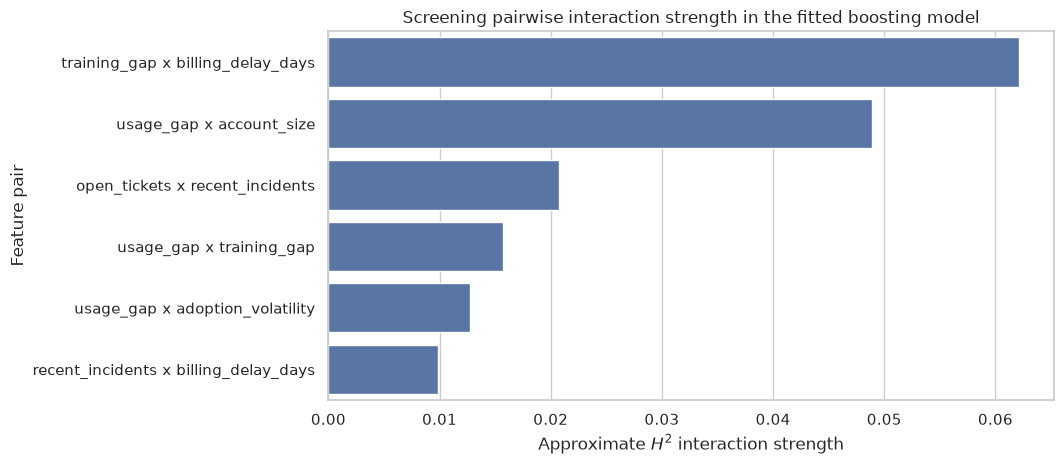

In [13]:
fig, ax = plt.subplots(figsize=(10.8, 4.8))
plot_table = interaction_table.copy()
plot_table['pair'] = plot_table['feature_a'] + ' x ' + plot_table['feature_b']
sns.barplot(data=plot_table, x='h2_interaction_strength', y='pair', ax=ax, color='#4c72b0')
ax.set_title('Screening pairwise interaction strength in the fitted boosting model')
ax.set_xlabel('Approximate $H^2$ interaction strength')
ax.set_ylabel('Feature pair')
plt.tight_layout()
plt.show()

The graphic gives us a way to see where the summary number is too compressed. For Friedman-Style Interaction Strength From Partial Dependence, look for where groups separate, where curves bend, or where the tails behave differently. The next decision should reflect these features, the aggregate score alone.


### Discussion of Interaction Strength

The table reports two complementary quantities. The normalized $H^2$ statistic asks what share of the joint surface variation is non-additive. The residual RMSE asks how large the non-additive part is on the prediction scale.

Those two rankings need not be identical. A pair can have a high normalized interaction share but a small absolute effect, or a modest normalized share but a large operational residual. For decision work, the absolute residual often deserves the next plot because it tells us where predicted risk is materially different from an additive summary.

A good workflow is:

1. screen plausible pairs with an interaction statistic;
2. inspect the response surface or subgroup PDP;
3. check whether the pattern occurs in supported regions of the data;
4. decide whether the pattern should affect model documentation, monitoring, or policy.

## 11. Interaction Residual Surface

Now we visualize the interaction residual surface for the pair with the largest **absolute residual magnitude**. The residual answers:

> Where is the joint fitted response higher or lower than an additive model would predict?

Positive residuals mean the pair creates extra predicted risk beyond the sum of the one-feature averages. Negative residuals mean the joint surface is lower than the additive approximation. This view is especially useful when a pair is operationally important even if its normalized $H^2$ value is not the largest.

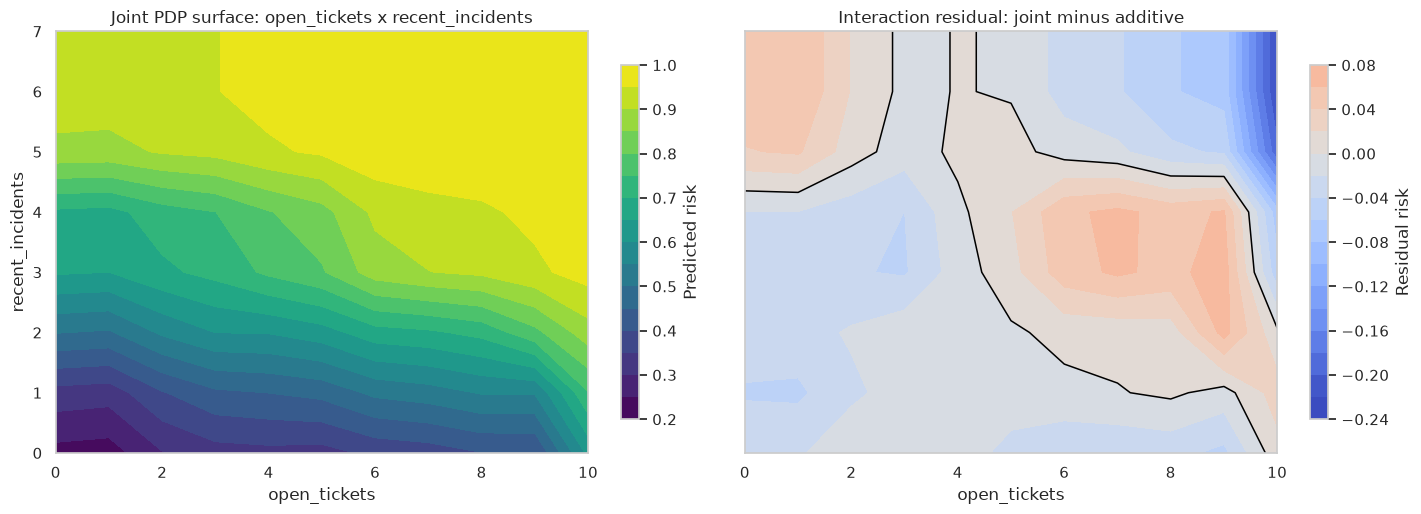

In [14]:
surface_pair_row = interaction_table.sort_values('rmse_interaction_residual', ascending=False).iloc[0]
top_pair = (surface_pair_row['feature_a'], surface_pair_row['feature_b'])
detail = interaction_details[top_pair]
residual = detail['residual']
grid_a = feature_grids[top_pair[0]]
grid_b = feature_grids[top_pair[1]]

fig, axes = plt.subplots(1, 2, figsize=(14.6, 5.3), sharex=True, sharey=True)

joint_plot = axes[0].contourf(grid_a, grid_b, detail['surface'], levels=16, cmap='viridis')
axes[0].set_title(f'Joint PDP surface: {top_pair[0]} x {top_pair[1]}')
axes[0].set_xlabel(top_pair[0])
axes[0].set_ylabel(top_pair[1])
fig.colorbar(joint_plot, ax=axes[0], shrink=0.84, label='Predicted risk')

lim = np.max(np.abs(residual))
resid_plot = axes[1].contourf(grid_a, grid_b, residual, levels=16, cmap='coolwarm', vmin=-lim, vmax=lim)
axes[1].contour(grid_a, grid_b, residual, levels=[0], colors='black', linewidths=1.1)
axes[1].set_title('Interaction residual: joint minus additive')
axes[1].set_xlabel(top_pair[0])
fig.colorbar(resid_plot, ax=axes[1], shrink=0.84, label='Residual risk')

plt.tight_layout()
plt.show()

The explanation result should be compared with the decision story. In Interaction Residual Surface, stable features, changing local reasons, and disagreement across explainers tell us how much trust to place in the model narrative. Explanation quality matters in practice because it shapes communication, review burden, and the defensibility of the recommendation.


### Discussion of the Residual Surface

The residual surface is often the clearest interaction diagnostic. A plain two-way PDP tells us the joint prediction. The residual surface tells us which part of that joint prediction cannot be explained by adding the two one-feature curves.

For decision systems, the most important regions are not necessarily the regions with the largest normalized interaction share. They are regions where all three things are true:

1. the residual is operationally meaningful;
2. the region has enough data support;
3. the pattern changes a decision, monitoring rule, or escalation threshold.

## 12. Support Diagnostics: Do The Surfaces Describe Realistic Accounts?

PDP and interaction surfaces can evaluate model predictions at feature combinations that are rare or unrealistic. This is especially risky when features are correlated. We need to ask whether the plotted grid overlaps with the observed data cloud.

A simple support diagnostic is to overlay the observed test points on the two-feature grid and mark low-density regions.

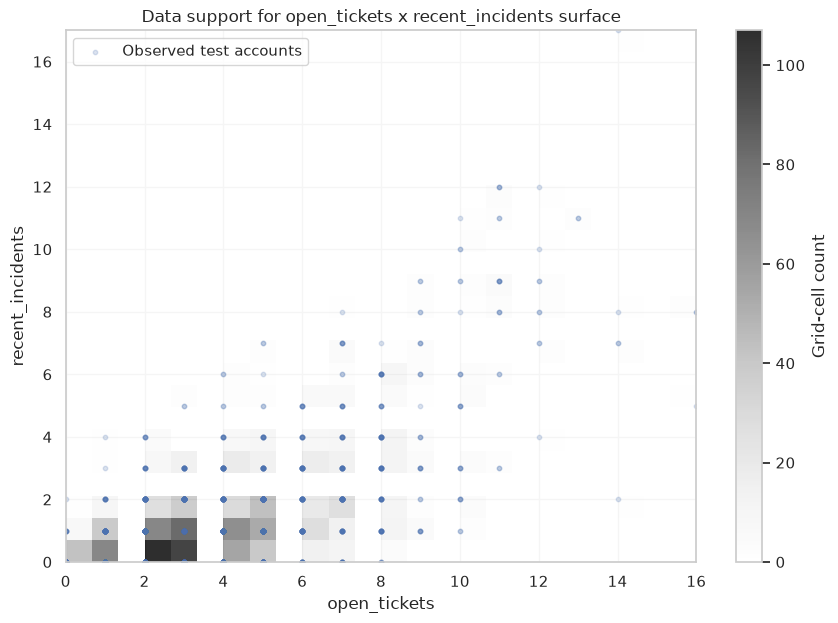

In [15]:
fig, ax = plt.subplots(figsize=(8.8, 6.4))

sample_support = test_df.sample(min(1300, len(test_df)), random_state=RANDOM_SEED)
hist = ax.hist2d(
    sample_support[top_pair[0]],
    sample_support[top_pair[1]],
    bins=24,
    cmap='Greys',
    alpha=0.82,
)
ax.scatter(sample_support[top_pair[0]], sample_support[top_pair[1]], s=10, alpha=0.20, color='#4c72b0', label='Observed test accounts')
ax.set_title(f'Data support for {top_pair[0]} x {top_pair[1]} surface')
ax.set_xlabel(top_pair[0])
ax.set_ylabel(top_pair[1])
ax.legend(loc='upper left')
fig.colorbar(hist[3], ax=ax, label='Grid-cell count')
plt.tight_layout()
plt.show()

The plot matters because it shows structure that a single summary number can hide. For Support Diagnostics: Do The Surfaces Describe Realistic Accounts?, look for where groups separate, where curves bend, or where the tails behave differently. Those features should shape the next choice about model class, threshold, monitoring, or human review.


### Discussion of Support

A response surface should not be interpreted uniformly across the entire rectangle. Corners with little data support are model extrapolations. They may be mathematically defined, but weakly evidenced.

This is the same support problem we saw in PDP, SHAP background choice, and LIME perturbation design. The plot is only as credible as the neighborhood it asks the model to explain.

## 13. Model Reliance Can Change By Segment

Global permutation importance reports one average reliance pattern. But reliance itself can vary by segment. We can compute permutation importance inside two groups and compare.

This is not a causal statement. It says the fitted model's predictive performance in one segment depends more on a feature than performance in another segment.

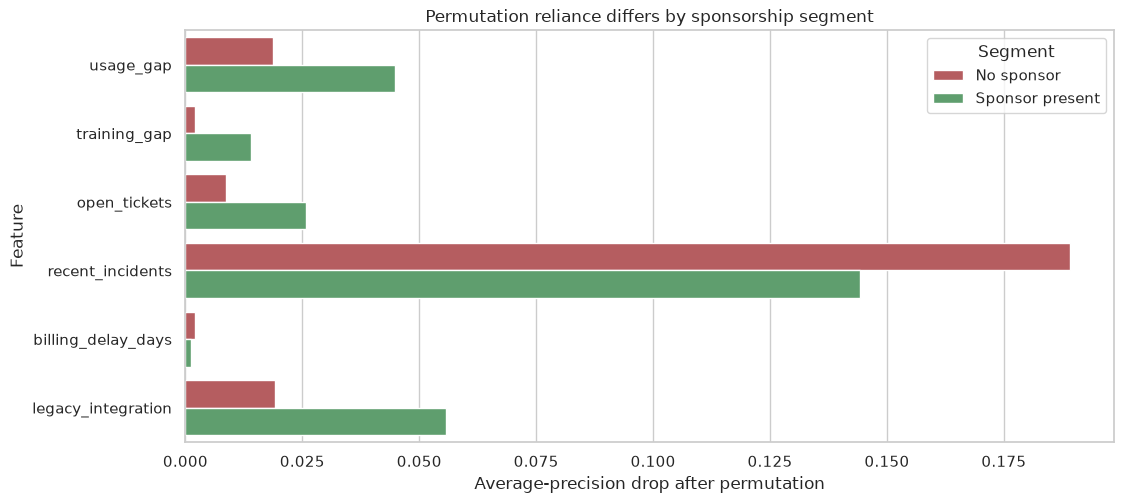

,feature,importance_mean,importance_sd,n,segment
5,billing_delay_days,0.002,0.001,960,No sponsor
16,billing_delay_days,0.001,0.002,900,Sponsor present
9,legacy_integration,0.019,0.002,960,No sponsor
20,legacy_integration,0.056,0.005,900,Sponsor present
3,open_tickets,0.009,0.002,960,No sponsor
14,open_tickets,0.026,0.005,900,Sponsor present
4,recent_incidents,0.189,0.010,960,No sponsor
15,recent_incidents,0.144,0.017,900,Sponsor present
2,training_gap,0.002,0.002,960,No sponsor
13,training_gap,0.014,0.004,900,Sponsor present


In [16]:
# Section focus: 13. Model Reliance Can Change By Segment.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

def segment_permutation(model, data, features, group_mask, scoring='average_precision', repeats=10, seed=RANDOM_SEED):
    """Carry out the segment permutation step used in the 10. Interactions, Heterogeneity, and Nonlinear Structure workflow.
    
    Parameters
    ----------
    model : object
        Fitted model or model specification used by this step.
    data : object
        Input data set used by this step of the notebook.
    features : object
        Feature column names or feature matrix used by the model.
    group_mask : object
        The group mask setting that controls the segment permutation calculation in this notebook.
    scoring : object
        The scoring setting that controls the segment permutation calculation in this notebook.
    repeats : object
        The repeats setting that controls the segment permutation calculation in this notebook.
    seed : object
        Random seed used to make the simulation reproducible.
    
    Returns
    -------
    object
        pandas.DataFrame containing the tabular result produced by this function.
    """
    subset = data.loc[group_mask].copy()
    result = permutation_importance(
        model,
        subset[features],
        subset[TARGET],
        scoring=scoring,
        n_repeats=repeats,
        random_state=seed,
        n_jobs=-1,
    )
    return pd.DataFrame({
        'feature': features,
        'importance_mean': result.importances_mean,
        'importance_sd': result.importances_std,
        'n': len(subset),
    })

perm_no_sponsor = segment_permutation(gradient_boosting, test_df, BASE_FEATURES, test_df['executive_sponsor'].eq(0))
perm_sponsor = segment_permutation(gradient_boosting, test_df, BASE_FEATURES, test_df['executive_sponsor'].eq(1))
perm_compare = (
    perm_no_sponsor.assign(segment='No sponsor')
    .pipe(lambda d: pd.concat([d, perm_sponsor.assign(segment='Sponsor present')], ignore_index=True))
)
plot_perm = perm_compare[perm_compare['feature'].isin(['recent_incidents', 'open_tickets', 'usage_gap', 'training_gap', 'legacy_integration', 'billing_delay_days'])]

fig, ax = plt.subplots(figsize=(11.4, 5.2))
sns.barplot(data=plot_perm, x='importance_mean', y='feature', hue='segment', ax=ax, palette={'No sponsor': '#c44e52', 'Sponsor present': '#55a868'})
ax.set_title('Permutation reliance differs by sponsorship segment')
ax.set_xlabel('Average-precision drop after permutation')
ax.set_ylabel('Feature')
ax.legend(title='Segment')
plt.tight_layout()
plt.show()

display_table(plot_perm.sort_values(['feature', 'segment']))

This result is an interpretation diagnostic. For Model Reliance Can Change By Segment, look at whether the explanation is stable, plausible, and useful for stakeholder review. A fragile narrative has value when the report is explicit about where it shifts.


### Discussion of Segment Reliance

Segment-specific reliance tells us whether the same fitted model uses evidence differently across operational contexts. Here, recent incidents matter in both groups, with a larger average-precision drop in the no-sponsor segment. Other features, such as legacy integration and usage gap, matter more in the sponsor-present segment. That richer pattern is more useful than saying one segment is simply more important than the other.

This is powerful, but it should be reported carefully. Segment reliance is partly a property of the model, partly a property of the segment data distribution, and partly a property of the chosen metric.

## 14. Decision-Science Reporting Template

A strong interaction report should answer five practical questions beyond showing a colorful surface:

| Reporting question | What to include |
|---|---|
| What interaction was tested? | Feature pair, model, prediction scale, and grid range |
| Why was it plausible? | Business logic, prior evidence, or screening statistic |
| Where does it matter? | Supported feature region and magnitude of predicted-risk change |
| Is it stable? | Retraining, bootstrap, or temporal checks when available |
| What can stakeholders do with it? | Monitoring rule, review trigger, caveat, or decision guardrail |

A useful wording pattern is:

> In the fitted model, recent incidents have a stronger association with predicted specialist-review risk when no executive sponsor is present. This is model-behavior evidence for closer review of no-sponsor accounts with repeated incidents. It should not be reported as a causal estimate of adding an executive sponsor without a causal design.

## 15. Key Takeaways

- Interactions are failures of additivity in a fitted prediction function.
- Response surfaces show joint model behavior, while residual surfaces isolate the non-additive part.
- ICE curves reveal heterogeneous model responses that PDPs can hide.
- Subgroup PDPs often communicate interactions more clearly to stakeholders than dense ICE plots.
- Friedman-style interaction strength is useful for screening feature pairs, but plots and support checks remain necessary.
- Interaction diagnostics describe the fitted model, not causal effect heterogeneity by themselves.
- A professional decision report ties interactions to supported regions, operational consequences, stability checks, and clear caveats.

## References

- Friedman, J. H., & Popescu, B. E. (2008). *Predictive learning via rule ensembles*. *The Annals of Applied Statistics, 2*(3). [https://doi.org/10.1214/07-AOAS148](https://doi.org/10.1214/07-AOAS148)
- Goldstein, A., Kapelner, A., Bleich, J., & Pitkin, E. (2015). *Peeking inside the black box: Visualizing statistical learning with plots of individual conditional expectation*. *Journal of Computational and Graphical Statistics, 24*(1), 44-65. [https://doi.org/10.1080/10618600.2014.907095](https://doi.org/10.1080/10618600.2014.907095)
- Greenwell, B. M. (2017). *pdp: An R package for constructing partial dependence plots*. *The R Journal, 9*(1), 421. [https://doi.org/10.32614/RJ-2017-016](https://doi.org/10.32614/RJ-2017-016)
- Oh, S. (2019). *Feature interaction in terms of prediction performance*. *Applied Sciences, 9*(23), 5191. [https://doi.org/10.3390/app9235191](https://doi.org/10.3390/app9235191)
